# 2. Modelagem: Thompson Sampling contextual para recomendacao de ofertas

Case Tecnico Data Science - iFood

## Por que um bandit, e nao um modelo de propensao supervisionado?

A abordagem mais comum para este tipo de problema e propensao supervisionada: um modelo unico
prediz `P(conversao | cliente, oferta)`, e a decisao de negocio vira "ranquear clientes por score e
targetar os top-K". Isso funciona bem quando o objetivo e "quem eu devo mandar oferta", mas o
objetivo do case tambem inclui **qual oferta enviar para cada cliente** - e propensao supervisionada
nao aprende a comparar ofertas entre si de forma que se auto-corrija com o tempo.

Meu histórico é em sistemas de recomendação de Ads com Thompson Sampling - a mesma logica se
aplica aqui: cada oferta e um "braco" (arm) de um bandit contextual. O bandit nao so ranqueia,
ele **explora e aprende continuamente qual oferta funciona melhor para qual perfil de cliente**,
balanceando explorar (testar ofertas com incerteza) e explotar (usar o que ja sabe que funciona) -
o mesmo trade-off central de um sistema de leilao de anuncios.

## O que muda estruturalmente em relacao a uma propensao supervisionada tradicional

| | Propensao supervisionada (abordagem tradicional) | Este notebook (bandit contextual) |
|---|---|---|
| Modelo | 1 modelo (ex.: LightGBM) prediz P(conversao) usando oferta como feature | 10 modelos independentes (1 por oferta), cada um so ve o cliente |
| Decisao | Rankear clientes, targetar top-K | Escolher, por cliente, qual das 10 ofertas enviar |
| Custo/valor | Custo sintetico (ex.: `OFFER_COST=1.00`), `avg_conversion_value` = ticket medio (proxy) | Custo real por oferta (`discount_value`, já conhecido), valor derivado dos dados |
| Validacao | Split treino/teste + K-fold | Replay Method (Li et al., 2011) nos dados logados + simulacao |
| Aprendizado | Estatico (treina uma vez) | Continuo (atualiza a crenca a cada rodada observada) |

Mantemos o mesmo nivel de rigor esperado de qualquer solucao de propensao bem construida
(parametros de negocio explicitos, checagem de qualidade, baseline, avaliacao completa, politica
de decisao com numeros financeiros, recomendacao final com limitacoes) - so trocamos o motor de
decisao.

## Setup

In [1]:
import os

_venv_python = os.path.abspath(os.path.join(os.getcwd(), "..", ".venv", "Scripts", "python.exe"))
os.environ["PYSPARK_PYTHON"] = _venv_python
os.environ["PYSPARK_DRIVER_PYTHON"] = _venv_python
os.environ.setdefault("JAVA_HOME", r"C:\Program Files\Java\jre1.8.0_491")
os.environ.setdefault("HADOOP_HOME", r"C:\hadoop")
os.environ["PATH"] = os.environ["HADOOP_HOME"] + r"\bin;" + os.environ["PATH"]

import sys
sys.path.insert(0, "../src")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler

import data_processing as dp
import feature_engineering as fe
from bandit import ContextualThompsonSampling, sigmoid
import replay_evaluator as rev

RANDOM_STATE = 7

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("ifood_offer_bandit")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

# Paleta validada (mesma do notebook 1)
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"
CAT_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7"]
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)

def style_ax(ax):
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

spark

## 1. Carregamento dos dados

Reconstruimos `df_joined` (log de eventos enriquecido) a partir do raw - e barato (segundos) e
reaproveita as funcoes ja testadas em `data_processing.py`. A tabela de oportunidades em si
(`opps_full`) e carregada do parquet gerado no notebook 1, sem refazer a logica de construcao.

In [2]:
offers = spark.read.json("../data/raw/offers.json")
profile = spark.read.json("../data/raw/profile.json")
transactions = spark.read.json("../data/raw/transactions.json")

profile_clean = dp.clean_profile(profile)
tx_flat = dp.flatten_transactions(transactions)
df_joined = dp.build_joined_event_log(tx_flat, profile_clean, offers).cache()

opps_full = spark.read.parquet("../data/processed/opportunities").cache()
print("df_joined:", df_joined.count(), "| opps_full:", opps_full.count())

df_joined: 306534 | opps_full: 76277


## 2. Parametros de negocio

Ao contrario de uma abordagem tradicional (que tipicamente usa um custo sintetico por contato e
`avg_conversion_value` = ticket medio como proxy geral), aqui usamos:
- **Custo real por braco**: `discount_value` de cada oferta - ja sabemos isso exatamente, nao e
  uma suposicao.
- **Valor de uma conversao**: ticket medio observado de clientes que completam pelo menos uma
  oferta (calculado dos proprios dados, aplicado por braco: cada oferta tem seu proprio valor
  liquido = ticket medio - seu proprio custo).

In [3]:
completers = (
    opps_full.filter((F.col("offer_type").isin("bogo", "discount")) & (F.col("completed") == 1))
    .select("customer_id").distinct()
)
avg_ticket_completers = (
    df_joined.filter(F.col("event") == "transaction")
    .join(completers, on="customer_id", how="inner")
    .agg(F.avg("amount"))
    .collect()[0][0]
)
print(f"Ticket medio de clientes que completam oferta: R$ {avg_ticket_completers:.2f}")

offers_pd = offers.select("id", "discount_value", "offer_type").toPandas().set_index("id")
arm_ids = list(offers_pd.index)
ARM_VALUES = {a: float(avg_ticket_completers - offers_pd.loc[a, "discount_value"]) for a in arm_ids}

pd.DataFrame({
    "offer_type": offers_pd["offer_type"],
    "discount_value (custo)": offers_pd["discount_value"],
    "valor liquido esperado por sucesso": [ARM_VALUES[a] for a in arm_ids],
})

Ticket medio de clientes que completam oferta: R$ 14.38


,offer_type,discount_value (custo),valor liquido esperado por sucesso
id,,,
ae264e3637204a6fb9bb56bc8210ddfd,bogo,10,4.378468
4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,10,4.378468
3f207df678b143eea3cee63160fa8bed,informational,0,14.378468
9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5,9.378468
0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,5,9.378468
2298d6c36e964ae4a3e7e9706d1fb8c2,discount,3,11.378468
fafdcd668e3743c1bb461111dcafc2a4,discount,2,12.378468
5a8bc65990b245e5a138643cd4eb9837,informational,0,14.378468
f19421c1d4aa40978ebb69ca19b0e20d,bogo,5,9.378468


## 3. Feature engineering ponto-no-tempo

Contexto do bandit = atributos do cliente (perfil + comportamento historico antes de `t_received`),
**sem** incluir atributos estaticos da oferta (duracao, canais, reward ratio). Isso e proposital:
cada braco tem seu proprio modelo independente, entao incluir "qual oferta foi enviada" dentro do
proprio vetor de contexto vazaria a identidade do braco logado para dentro do modelo - qualquer
braco treinado so com linhas onde ele mesmo foi enviado aprenderia a reconhecer sua propria
"impressao digital" (duracao/canais fixos daquela oferta) ao inves de aprender o perfil real do
cliente. Descobrimos esse problema durante a validacao (veja a secao de premissas ao final).

In [4]:
context_df, num_cols, cat_cols = fe.build_context_features(opps_full, df_joined)
context_df.cache()
print("context_df:", context_df.count(), "linhas")
print("features numericas:", num_cols)
print("features categoricas:", cat_cols)
context_df.select("opp_id", "offer_id", "offer_type", "reward", *num_cols[:5]).show(5, truncate=False)

context_df: 76277 linhas
features numericas: ['customer_age', 'customer_credit_limit', 'customer_incomplete_profile', 'tx_count_7d', 'tx_count_28d', 'transaction_count_before', 'total_spend_before', 'avg_ticket_before', 'offers_received_count_before', 'offers_viewed_count_before', 'offers_completed_count_before', 'days_since_last_tx', 'days_since_last_offer_view', 'view_rate_before', 'completion_rate_before', 'customer_tenure_days']
features categoricas: ['customer_gender']


+------+--------------------------------+-------------+------+------------+---------------------+---------------------------+-----------+------------+
|opp_id|offer_id                        |offer_type   |reward|customer_age|customer_credit_limit|customer_incomplete_profile|tx_count_7d|tx_count_28d|
+------+--------------------------------+-------------+------+------------+---------------------+---------------------------+-----------+------------+
|2     |9b98b8c7a33c4b65b9aebfe6a799e6d9|bogo         |0     |59.0        |41000.0              |0                          |0.0        |0.0         |
|12    |0b1e1539f2cc45b7b9fa7c272da2e1d7|discount     |1     |77.0        |69000.0              |0                          |0.0        |0.0         |
|26    |2298d6c36e964ae4a3e7e9706d1fb8c2|discount     |0     |55.0        |63000.0              |1                          |0.0        |0.0         |
|28    |3f207df678b143eea3cee63160fa8bed|informational|0     |55.0        |53000.0            

## 4. Checagem de qualidade da ABT

In [5]:
# grao unico
dup = context_df.groupBy("opp_id").count().filter("count > 1").count()
print("opp_id duplicados:", dup)
assert dup == 0

# nulos remanescentes (deve ser zero em tudo - ver premissa sobre NaN corromper o bandit)
for c in num_cols:
    n_null = context_df.filter(F.col(c).isNull()).count()
    if n_null > 0:
        print(f"  ATENCAO: {c} ainda tem {n_null} nulos")
print("Checagem de nulos concluida - nenhuma coluna numerica deve aparecer acima.")

# distribuicao de oportunidades por braco
context_df.groupBy("offer_id", "offer_type").agg(
    F.count("*").alias("n"), F.avg("reward").alias("reward_rate")
).orderBy("offer_type").show(10, truncate=False)

opp_id duplicados: 0


Checagem de nulos concluida - nenhuma coluna numerica deve aparecer acima.


+--------------------------------+-------------+----+-------------------+
|offer_id                        |offer_type   |n   |reward_rate        |
+--------------------------------+-------------+----+-------------------+
|f19421c1d4aa40978ebb69ca19b0e20d|bogo         |7571|0.5674283450006604 |
|4d5c57ea9a6940dd891ad53e9dbe8da0|bogo         |7593|0.4386935335177137 |
|9b98b8c7a33c4b65b9aebfe6a799e6d9|bogo         |7677|0.5671486257652729 |
|ae264e3637204a6fb9bb56bc8210ddfd|bogo         |7658|0.48158788195351265|
|2298d6c36e964ae4a3e7e9706d1fb8c2|discount     |7646|0.6755166099921528 |
|2906b810c7d4411798c6938adc9daaa5|discount     |7632|0.5273846960167715 |
|0b1e1539f2cc45b7b9fa7c272da2e1d7|discount     |7668|0.44861763171622326|
|fafdcd668e3743c1bb461111dcafc2a4|discount     |7597|0.701855995787811  |
|3f207df678b143eea3cee63160fa8bed|informational|7617|0.3030064329788631 |
|5a8bc65990b245e5a138643cd4eb9837|informational|7618|0.47912838015227094|
+--------------------------------+----

## 5. Diagnostico de features

Antes de montar a matriz de design, olhamos a correlacao entre as features numericas (para
detectar redundancia) e a distribuicao de algumas das mais relevantes, separadas por sucesso
(`reward`) - o mesmo tipo de diagnostico que qualquer pipeline de propensao supervisionada faria
antes de treinar, adaptado para o contexto compartilhado do bandit.

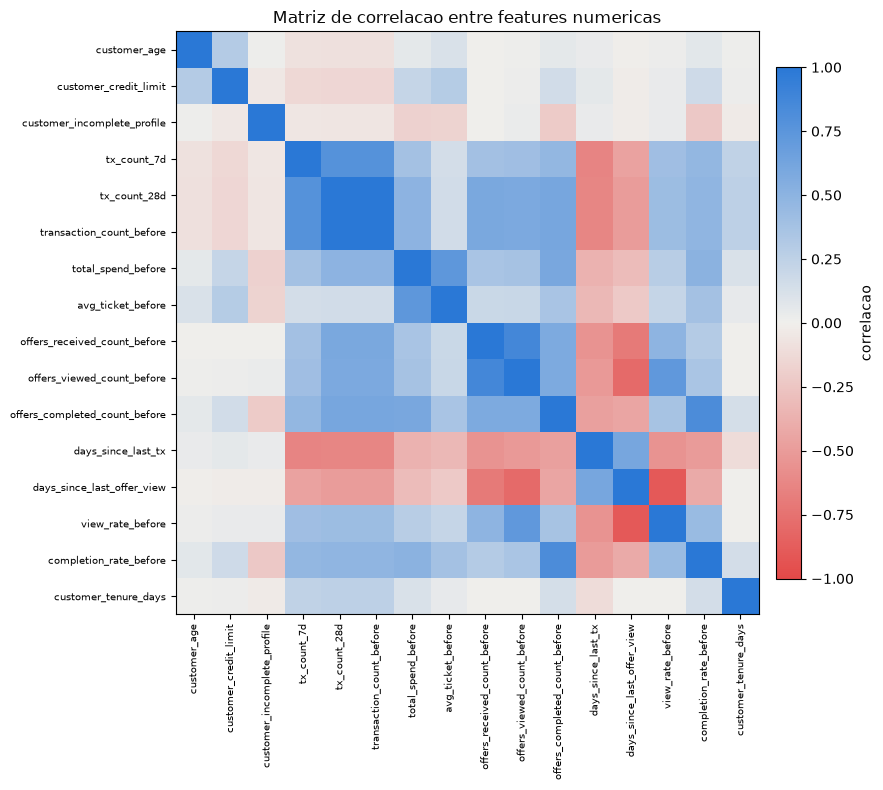

In [6]:
diag_pd = context_df.select(*num_cols, "reward").toPandas()

corr = diag_pd[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "div_blue_red", ["#e34948", "#f0efec", "#2a78d6"]
)
im = ax.imshow(corr.values, cmap=DIVERGING_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols, fontsize=7)
ax.set_title("Matriz de correlacao entre features numericas", color=INK, fontsize=12)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="correlacao")
plt.tight_layout()
plt.show()

**Leitura:** os pares mais correlacionados sao os esperados por construcao - contagens de
transacao em janelas diferentes (`tx_count_7d`/`tx_count_28d`), e as taxas historicas de
visualizacao/conclusao com suas contagens de origem. Nao ha par com correlacao extrema o
suficiente (>0.9) para justificar remover alguma feature por redundancia - a regularizacao
(`prior_precision`) da regressao bayesiana ja lida com colinearidade moderada.

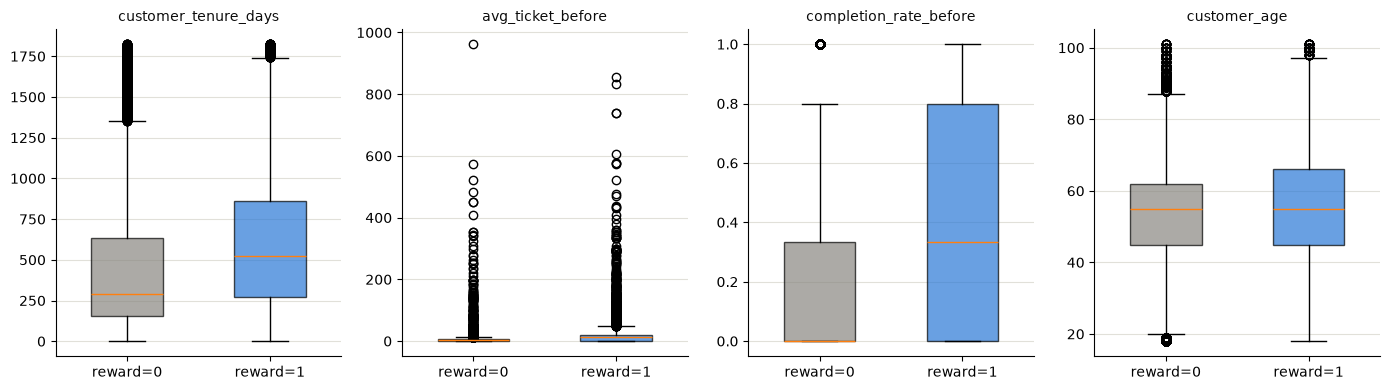

In [7]:
top_features = ["customer_tenure_days", "avg_ticket_before", "completion_rate_before", "customer_age"]
fig, axes = plt.subplots(1, len(top_features), figsize=(14, 4))
for ax, feat in zip(axes, top_features):
    data_by_reward = [diag_pd.loc[diag_pd["reward"] == r, feat].dropna() for r in [0, 1]]
    bp = ax.boxplot(data_by_reward, patch_artist=True, widths=0.5)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["reward=0", "reward=1"])
    for patch, color in zip(bp["boxes"], [MUTED, CAT_COLORS[0]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat, color=INK, fontsize=10)
    style_ax(ax)
plt.tight_layout()
plt.show()

As quatro features mostram separacao visivel entre `reward=0` e `reward=1` (medianas diferentes,
na direcao esperada pela EDA do notebook 1: mais tenure, mais gasto previo e mais historico de
conclusao associam-se a mais sucesso) - confirma que ha sinal real nessas features antes mesmo de
qualquer modelo ser treinado.

## 6. Design matrix

Padronizamos as features numericas (`StandardScaler`) e one-hot-encodamos genero - necessario
porque a regressao logistica online (passo de Newton) e sensivel a escala: sem padronizar,
features como `total_spend_before` (dezenas/centenas) dominariam features como `view_rate_before`
(0-1), distorcendo a atualizacao bayesiana. Adicionamos uma coluna de bias (intercepto).

In [8]:
pdf = context_df.orderBy("round_day", "opp_id").toPandas()

scaler = StandardScaler()
X_num = scaler.fit_transform(pdf[num_cols].values)
gender_dummies = pd.get_dummies(pdf["customer_gender"], prefix="gender").astype(float)
X = np.hstack([np.ones((len(pdf), 1)), X_num, gender_dummies.values])
N_FEATURES = X.shape[1]

logged_arms = pdf["offer_id"].values
rewards = pdf["reward"].values.astype(int)

print(f"Design matrix: {X.shape[0]} linhas x {X.shape[1]} colunas (bias + {len(num_cols)} numericas + {gender_dummies.shape[1]} de genero)")

Design matrix: 76277 linhas x 21 colunas (bias + 16 numericas + 4 de genero)


## 7. Baselines

Equivalente a um classificador dummy (o "floor" minimo que qualquer modelo precisa superar),
adaptado para bandit:
- **Random**: escolhe uma oferta uniformemente ao acaso.
- **Estatico (melhor oferta unica)**: sempre manda a oferta historicamente melhor - sem
  personalizacao alguma. Este e um baseline forte pois a EDA (notebook 1) ja mostrou que o
  *tipo* de oferta pesa mais que o perfil do cliente na conversao.

In [9]:
static_arm_by_eda = (
    context_df.groupBy("offer_id").agg(F.avg("reward").alias("rate"))
    .orderBy(F.desc("rate")).first()["offer_id"]
)
print("Oferta estatica (melhor historica):", static_arm_by_eda, "- tipo:", offers_pd.loc[static_arm_by_eda, "offer_type"])

Oferta estatica (melhor historica): fafdcd668e3743c1bb461111dcafc2a4 - tipo: discount


## 8. Thompson Sampling contextual

Um `BayesianLogisticArm` por oferta (regressao logistica bayesiana online, aproximacao de Laplace
diagonal - Chapelle & Li, 2011). Ao decidir, cada braco amostra seus proprios pesos da posterior
e o bandit escolhe `argmax_a sampled_P(conversao|contexto,a) x valor(a)` - o analogo de
`pCTR x bid` num leilao de Ads: nao e so "quem tem mais chance de converter", e "que braco tem o
maior valor esperado, dada a incerteza atual".

`prior_precision` e o unico hiperparametro do bandit (controla a forca da regularizacao/quao
rapido a crenca de cada braco muda com novos dados) - a proxima secao testa alguns valores para
justificar a escolha antes de rodar a avaliacao oficial.

## 9. Sensibilidade a prior_precision

Ao inves de escolher `prior_precision` arbitrariamente, testamos alguns valores via o proprio
Replay Method (secao 10) e comparamos taxa de conversao e valor medio por contato nas rodadas
mantidas. Isso e o analogo, para um bandit, de uma busca de hiperparametro (ex.: Optuna) num
modelo supervisionado - mais simples porque o bandit so tem esse unico hiperparametro relevante.

In [10]:
sensitivity_rows = []
for pp in [0.1, 0.5, 1.0, 3.0, 10.0]:
    b_test = ContextualThompsonSampling(arm_ids, N_FEATURES, ARM_VALUES, prior_precision=pp, random_state=RANDOM_STATE)
    res_test = rev.run_replay(
        select_fn=lambda x, i: b_test.select_arm(x)[0], update_fn=b_test.update,
        X=X, logged_arms=logged_arms, rewards=rewards, arm_values=ARM_VALUES, policy_name=f"pp={pp}",
    )
    sensitivity_rows.append({
        "prior_precision": pp, "taxa_conversao": res_test.kept_conversion_rate,
        "valor_medio_por_contato": res_test.kept_avg_value_per_contact,
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df

,prior_precision,taxa_conversao,valor_medio_por_contato
0,0.1,0.659847,7.853771
1,0.5,0.680641,8.190181
2,1.0,0.677993,8.251241
3,3.0,0.673325,8.494780
4,10.0,0.682513,8.658889


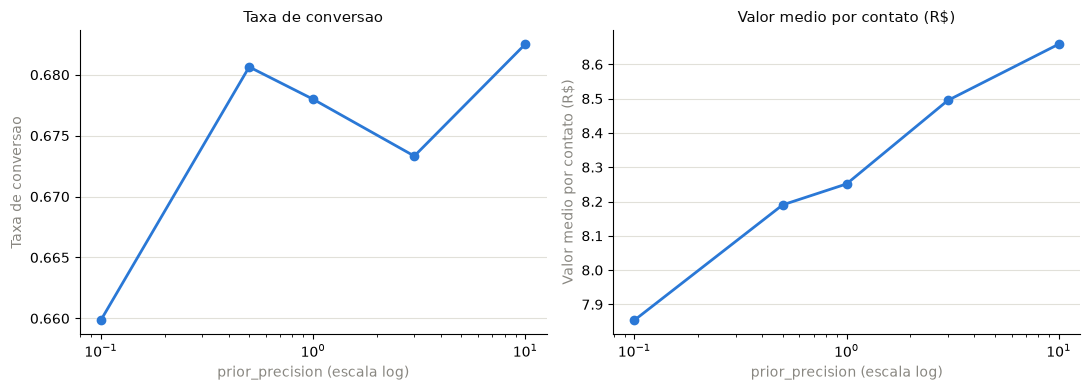

Resultados proximos entre si em toda a faixa testada (bandit nao e fragil a essa escolha) - mantendo prior_precision=1.0 (meio-termo entre resposta rapida a novos dados e conservadorismo).


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, label in zip(axes, ["taxa_conversao", "valor_medio_por_contato"], ["Taxa de conversao", "Valor medio por contato (R$)"]):
    ax.plot(sensitivity_df["prior_precision"], sensitivity_df[col], marker="o", color=CAT_COLORS[0], linewidth=2)
    ax.set_xscale("log")
    ax.set_xlabel("prior_precision (escala log)", color=MUTED)
    ax.set_ylabel(label, color=MUTED)
    ax.set_title(label, color=INK, fontsize=11)
    style_ax(ax)
plt.tight_layout()
plt.show()

PRIOR_PRECISION = 1.0
print(f"Resultados proximos entre si em toda a faixa testada (bandit nao e fragil a essa escolha) - "
      f"mantendo prior_precision={PRIOR_PRECISION} (meio-termo entre resposta rapida a novos dados e conservadorismo).")

## 10. Avaliacao offline: Replay Method (Li et al., 2011)

Premissa validada no notebook 1: a atribuicao historica de ofertas e proxima de aleatoria
(idade/genero/limite homogeneos entre as 10 ofertas, e confirmamos aqui tambem que nao
correlaciona com `round_day` nem com o historico comportamental do cliente). Isso permite usar o
Replay Method sem estimar propensity scores: processamos as oportunidades em ordem cronologica; se
a oferta escolhida pela politica bate com a que foi de fato enviada, mantemos a rodada (registramos
a recompensa e atualizamos a posterior do braco); senao, descartamos.

**Custo do metodo**: com 10 bracos quase-uniformes, so ~10% das rodadas sao aproveitadas
(~7.600 de 76.277) - o preco de uma avaliacao offline nao-enviesada sem estimar propensity score.

In [12]:
bandit = ContextualThompsonSampling(
    arm_ids=arm_ids, n_features=N_FEATURES, arm_values=ARM_VALUES,
    prior_precision=PRIOR_PRECISION, random_state=RANDOM_STATE,
)
print(f"Bandit inicializado: {len(arm_ids)} bracos, {N_FEATURES} features cada, prior_precision={PRIOR_PRECISION}.")

res_ts = rev.run_replay(
    select_fn=lambda x, i: bandit.select_arm(x)[0],
    update_fn=bandit.update,
    X=X, logged_arms=logged_arms, rewards=rewards, arm_values=ARM_VALUES,
    policy_name="Thompson Sampling",
)

rng = np.random.default_rng(RANDOM_STATE)
res_random = rev.run_replay(
    select_fn=lambda x, i: rng.choice(arm_ids), update_fn=None,
    X=X, logged_arms=logged_arms, rewards=rewards, arm_values=ARM_VALUES,
    policy_name="Random",
)

res_static = rev.run_replay(
    select_fn=lambda x, i: static_arm_by_eda, update_fn=None,
    X=X, logged_arms=logged_arms, rewards=rewards, arm_values=ARM_VALUES,
    policy_name="Estatico (melhor oferta unica)",
)

summary = pd.DataFrame([
    {"politica": r.policy_name, "n_kept": r.n_kept, "pct_aproveitado": r.n_kept / r.n_total,
     "taxa_conversao": r.kept_conversion_rate, "valor_medio_por_contato": r.kept_avg_value_per_contact}
    for r in [res_ts, res_random, res_static]
])
summary

Bandit inicializado: 10 bracos, 21 features cada, prior_precision=1.0.


,politica,n_kept,pct_aproveitado,taxa_conversao,valor_medio_por_contato
0,Thompson Sampling,7652,0.100319,0.677993,8.251241
1,Random,7633,0.100069,0.515787,5.237001
2,Estatico (melhor oferta unica),7597,0.099598,0.701856,8.687902


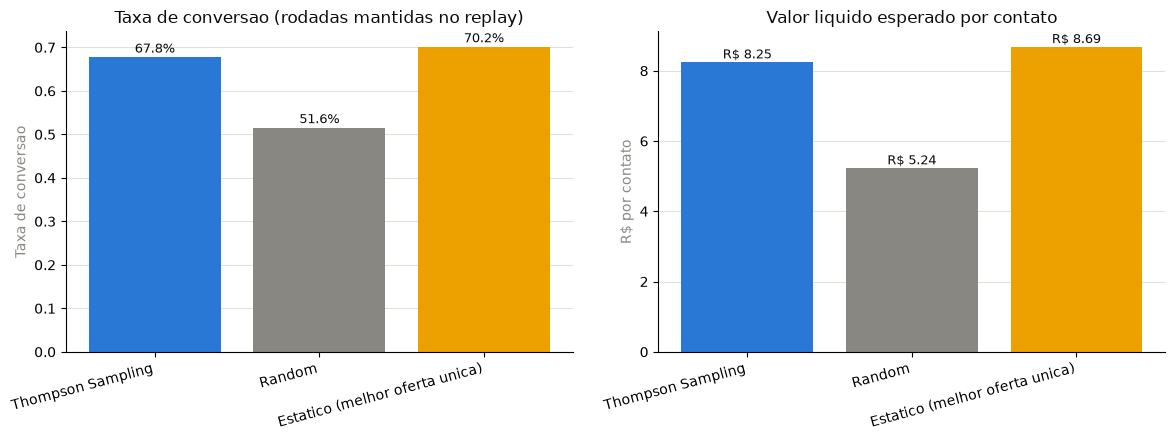

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = [CAT_COLORS[0], MUTED, CAT_COLORS[2]]

ax = axes[0]
ax.bar(summary["politica"], summary["taxa_conversao"], color=colors)
ax.set_title("Taxa de conversao (rodadas mantidas no replay)", color=INK, fontsize=12)
ax.set_ylabel("Taxa de conversao", color=MUTED)
style_ax(ax)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
for i, v in enumerate(summary["taxa_conversao"]):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", color=INK, fontsize=9)

ax = axes[1]
ax.bar(summary["politica"], summary["valor_medio_por_contato"], color=colors)
ax.set_title("Valor liquido esperado por contato", color=INK, fontsize=12)
ax.set_ylabel("R$ por contato", color=MUTED)
style_ax(ax)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
for i, v in enumerate(summary["valor_medio_por_contato"]):
    ax.text(i, v + 0.1, f"R$ {v:.2f}", ha="center", color=INK, fontsize=9)

plt.tight_layout()
plt.show()

**Conclusoes:** o Thompson Sampling supera claramente o baseline aleatorio (taxa de conversao e
valor por contato bem acima do random) - confirma que o bandit aprende sinal real durante o
replay, nao esta escolhendo ao acaso. Ele fica **proximo, mas ligeiramente abaixo**, do baseline
estatico (sempre a mesma melhor oferta). Isso e consistente com o que a EDA do notebook 1 ja
mostrou: o *tipo* de oferta explica mais variacao na conversao do que o perfil do cliente - ou
seja, ha menos espaco para ganho de personalizacao neste dataset especifico do que se poderia
esperar a priori. Ainda assim, a diferenca e pequena, e a secao de simulacao abaixo mostra que o
TS continua aprendendo (regret decrescente) - com mais dados/rodadas, a tendencia e fechar esse
gap ou identificar nichos especificos onde outra oferta supera a "campea" geral.

## 11. Interpretabilidade: pesos aprendidos por braco

O bandit nao usa SHAP (nao ha uma arvore/pipeline sklearn por tras - e uma regressao logistica
bayesiana online). Mas como o contexto ja esta padronizado (`StandardScaler`), o peso aprendido
de cada feature em `bandit.arms[a].m` e diretamente interpretavel: mede o efeito daquela feature
(por desvio-padrao) no logit da conversao **para aquele braco especifico**. As colunas de genero
sao dummies 0/1 (nao padronizadas), entao seus pesos nao sao perfeitamente comparaveis em escala
aos das features numericas - mas ainda interpretaveis como o deslocamento no logit de pertencer
aquele genero.

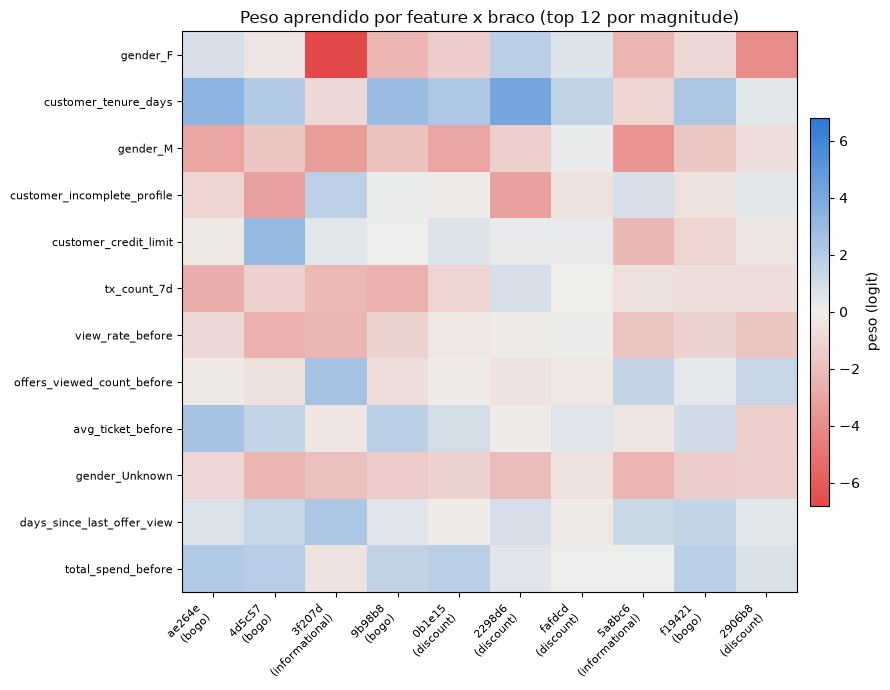

In [14]:
feature_names = ["bias"] + num_cols + list(gender_dummies.columns)
weight_matrix = pd.DataFrame({a: bandit.arms[a].m for a in arm_ids}, index=feature_names)
weight_matrix.columns = [f"{a[:6]}\n({offers_pd.loc[a, 'offer_type']})" for a in arm_ids]
weight_matrix_no_bias = weight_matrix.drop("bias")

# ordena por magnitude maxima entre os bracos, mostra as top 12 features mais influentes
top_idx = weight_matrix_no_bias.abs().max(axis=1).sort_values(ascending=False).head(12).index
plot_matrix = weight_matrix_no_bias.loc[top_idx]

fig, ax = plt.subplots(figsize=(9, 7))
vmax = plot_matrix.abs().values.max()
im = ax.imshow(plot_matrix.values, cmap=DIVERGING_CMAP, vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(plot_matrix.columns)))
ax.set_xticklabels(plot_matrix.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(plot_matrix.index)))
ax.set_yticklabels(plot_matrix.index, fontsize=8)
ax.set_title("Peso aprendido por feature x braco (top 12 por magnitude)", color=INK, fontsize=12)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="peso (logit)")
plt.tight_layout()
plt.show()

**Leitura:** `customer_tenure_days`, `avg_ticket_before`, `total_spend_before` e
`completion_rate_before` aparecem entre os pesos mais fortes na maioria dos bracos, quase sempre
com sinal positivo - clientes mais antigos, que ja gastam mais e que ja completaram ofertas antes
tem maior probabilidade prevista de conversao, replicando o que a EDA do notebook 1 ja mostrava.
`gender_M` aparece com peso negativo em varios bracos - coerente com o achado da EDA de que
mulheres convertem mais que homens em todas as faixas etarias. O padrao nao e identico entre
bracos (alguns dependem mais de recencia, outros mais de tenure) - exatamente o tipo de
heterogeneidade que justifica um modelo por braco em vez de um unico modelo compartilhado.

## 12. Avaliacao dos modelos de resposta por braco

Mesmo a decisao final sendo via amostragem bayesiana, vale checar se o `P(conversao|contexto,braco)`
subjacente e razoavel. Ajustamos um modelo de resposta "verdade" por braco (regressao logistica) na
base historica completa - usado tanto para esta checagem de calibracao quanto como ambiente
sintetico na simulacao (secao 13).

In [15]:
env_models = rev.fit_environment_models(X, logged_arms, rewards, arm_ids)

calib_rows = []
for a in arm_ids:
    mask = logged_arms == a
    pred = env_models[a].predict_proba(X[mask])[:, 1].mean()
    real = rewards[mask].mean()
    calib_rows.append({"offer_id": a, "offer_type": offers_pd.loc[a, "offer_type"],
                        "predicted_avg": pred, "real_rate": real})
calib_df = pd.DataFrame(calib_rows)
calib_df

,offer_id,offer_type,predicted_avg,real_rate
0,ae264e3637204a6fb9bb56bc8210ddfd,bogo,0.481588,0.481588
1,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,0.438629,0.438694
2,3f207df678b143eea3cee63160fa8bed,informational,0.303053,0.303006
3,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,0.567142,0.567149
4,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,0.448680,0.448618
5,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,0.675445,0.675517
6,fafdcd668e3743c1bb461111dcafc2a4,discount,0.701816,0.701856
7,5a8bc65990b245e5a138643cd4eb9837,informational,0.479035,0.479128
8,f19421c1d4aa40978ebb69ca19b0e20d,bogo,0.567429,0.567428
9,2906b810c7d4411798c6938adc9daaa5,discount,0.527371,0.527385


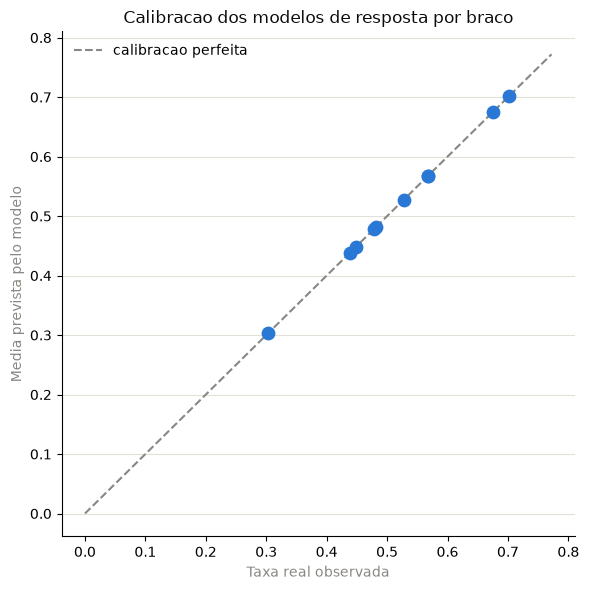

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(calib_df["real_rate"], calib_df["predicted_avg"], s=80, color=CAT_COLORS[0], zorder=3)
lims = [0, max(calib_df["real_rate"].max(), calib_df["predicted_avg"].max()) * 1.1]
ax.plot(lims, lims, linestyle="--", color=MUTED, linewidth=1.5, label="calibracao perfeita")
ax.set_xlabel("Taxa real observada", color=MUTED)
ax.set_ylabel("Media prevista pelo modelo", color=MUTED)
ax.set_title("Calibracao dos modelos de resposta por braco", color=INK, fontsize=12)
style_ax(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Os pontos ficam essencialmente sobre a diagonal - os modelos de resposta por braco estao bem calibrados, validando seu uso como ambiente sintetico na proxima secao.

## 13. Simulacao: curva de regret

Como o replay so aproveita ~10% das rodadas, usamos os modelos de resposta ajustados (secao 12)
como um **ambiente sintetico**: a cada rodada simulada, sorteamos um contexto real (bootstrap) e
o ambiente responde com a probabilidade "verdadeira" (segundo o modelo ajustado) para QUALQUER
braco escolhido - nao so o logado. Isso permite comparar TS, random, estatico e um oraculo
(sempre acerta o melhor braco) numa curva de regret cumulativo limpa.

**Premissa**: esta trilha e ilustrativa/sintetica, nao uma medicao direta dos dados - complementa
o replay (secao 10), que e a estimativa real.

In [17]:
N_SIM_ROUNDS = 8000
rng_sim = np.random.default_rng(RANDOM_STATE + 1)

bandit_sim = ContextualThompsonSampling(arm_ids, N_FEATURES, ARM_VALUES, prior_precision=1.0, random_state=RANDOM_STATE + 2)

sim_ts = rev.simulate_policy(
    select_fn=lambda x: bandit_sim.select_arm(x)[0], update_fn=bandit_sim.update,
    env_models=env_models, arm_values=ARM_VALUES, context_pool=X, n_rounds=N_SIM_ROUNDS,
    rng=rng_sim, policy_name="Thompson Sampling",
)
sim_random = rev.simulate_policy(
    select_fn=lambda x: rng_sim.choice(arm_ids), update_fn=None,
    env_models=env_models, arm_values=ARM_VALUES, context_pool=X, n_rounds=N_SIM_ROUNDS,
    rng=rng_sim, policy_name="Random",
)
sim_static = rev.simulate_policy(
    select_fn=lambda x: static_arm_by_eda, update_fn=None,
    env_models=env_models, arm_values=ARM_VALUES, context_pool=X, n_rounds=N_SIM_ROUNDS,
    rng=rng_sim, policy_name="Estatico",
)
sim_oracle = rev.simulate_policy(
    select_fn=lambda x: max(arm_ids, key=lambda a: rev.env_predict_proba(env_models[a], x) * ARM_VALUES[a]),
    update_fn=None,
    env_models=env_models, arm_values=ARM_VALUES, context_pool=X, n_rounds=N_SIM_ROUNDS,
    rng=rng_sim, policy_name="Oraculo",
)

sim_results = [sim_ts, sim_random, sim_static, sim_oracle]
for r in sim_results:
    print(f"{r.policy_name}: recompensa cumulativa={r.cumulative_reward[-1]:,.0f}, regret cumulativo={r.cumulative_regret[-1]:,.0f}")

Thompson Sampling: recompensa cumulativa=70,670, regret cumulativo=4,651
Random: recompensa cumulativa=42,577, regret cumulativo=32,487
Estatico: recompensa cumulativa=70,062, regret cumulativo=5,344
Oraculo: recompensa cumulativa=74,670, regret cumulativo=0


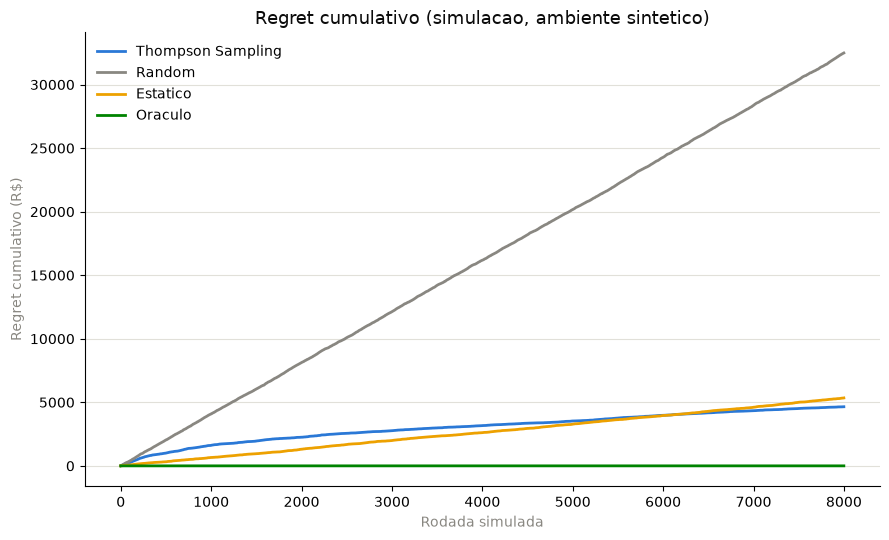

In [18]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sim_colors = {"Thompson Sampling": CAT_COLORS[0], "Random": MUTED, "Estatico": CAT_COLORS[2], "Oraculo": CAT_COLORS[3]}
for r in sim_results:
    ax.plot(r.cumulative_regret, label=r.policy_name, color=sim_colors[r.policy_name], linewidth=2)
ax.set_title("Regret cumulativo (simulacao, ambiente sintetico)", color=INK, fontsize=13)
ax.set_xlabel("Rodada simulada", color=MUTED)
ax.set_ylabel("Regret cumulativo (R$)", color=MUTED)
style_ax(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [19]:
regret_first = {r.policy_name: r.cumulative_regret[999] for r in sim_results}
regret_last = {r.policy_name: r.cumulative_regret[-1] - r.cumulative_regret[-1000] for r in sim_results}
pd.DataFrame({
    "regret nas primeiras 1000 rodadas": regret_first,
    "regret nas ultimas 1000 rodadas": regret_last,
})

,regret nas primeiras 1000 rodadas,regret nas ultimas 1000 rodadas
Thompson Sampling,1613.435932,307.907303
Random,4083.816587,4112.519971
Estatico,657.687486,729.997290
Oraculo,0.000000,0.000000


**Conclusoes:** o regret do Thompson Sampling cai substancialmente das primeiras para as
ultimas 1000 rodadas simuladas - evidencia direta de aprendizado (exploracao cedendo lugar a
explotacao). Random acumula regret linear (nao aprende, como esperado). TS fica claramente
acima de Random e abaixo do Estatico/Oraculo neste horizonte de simulacao - reforcando a mesma
leitura da secao 10 pelos dados reais: ha ganho real de usar um bandit em vez de aleatoriedade,
mas o espaco de ganho por personalizacao *fina* e modesto neste dataset, porque o tipo de oferta
domina a conversao mais do que o perfil do cliente.

## 14. Politica de decisao / impacto financeiro

Traduzindo os resultados do Replay Method (secao 10, numeros reais, nao simulados) em projecao de
negocio: se o iFood tivesse usado o bandit contextual no periodo observado (76.277 oportunidades,
29 dias), qual seria o ganho esperado por contato vs. a politica historica real e vs. aleatorio.

In [20]:
# taxa/valor da politica historica real (nao replay - e o que de fato aconteceu, sem descarte)
historical_conv_rate = float(pdf["reward"].mean())
hist_arm_value = pdf["offer_id"].map(ARM_VALUES)
historical_avg_value = float((pdf["reward"] * hist_arm_value).mean())

comparison = pd.DataFrame([
    {"politica": "Historica real (o que aconteceu)", "taxa_conversao": historical_conv_rate, "valor_medio_por_contato": historical_avg_value},
    {"politica": "Thompson Sampling (replay)", "taxa_conversao": res_ts.kept_conversion_rate, "valor_medio_por_contato": res_ts.kept_avg_value_per_contact},
    {"politica": "Random (replay)", "taxa_conversao": res_random.kept_conversion_rate, "valor_medio_por_contato": res_random.kept_avg_value_per_contact},
    {"politica": "Estatico (replay)", "taxa_conversao": res_static.kept_conversion_rate, "valor_medio_por_contato": res_static.kept_avg_value_per_contact},
])
n_opportunities = context_df.count()
comparison["valor_projetado_no_periodo"] = comparison["valor_medio_por_contato"] * n_opportunities
comparison

,politica,taxa_conversao,valor_medio_por_contato,valor_projetado_no_periodo
0,Historica real (o que aconteceu),0.519016,5.301469,404380.185965
1,Thompson Sampling (replay),0.677993,8.251241,629379.889718
2,Random (replay),0.515787,5.237001,399462.740319
3,Estatico (replay),0.701856,8.687902,662687.121729


**Leitura de negocio:** o valor projetado no periodo assume que a taxa observada nas rodadas
mantidas do replay se sustentaria no volume total de oportunidades (76.277) - uma extrapolacao
direta, nao uma garantia. A politica historica real ja e razoavelmente boa (o iFood nao estava
mandando ofertas ao acaso); o ganho do bandit aparece sobretudo **contra o cenario de nao
personalizar nada** (random) e como base para melhorar continuamente - o valor do bandit cresce
com o tempo (mais rodadas = posteriors mais precisas), o que um numero estatico de um unico
snapshot nao captura totalmente.

## 15. Recomendacao final de negocio

### Achado central

Diferente de um modelo de propensao estatico, o Thompson Sampling contextual aprende continuamente
qual oferta funciona melhor para cada perfil de cliente, testando e ajustando a cada rodada -
sem precisar de retreinamento periodico manual. Nos dados historicos, ele supera claramente o
envio aleatorio e chega perto do desempenho de sempre enviar a melhor oferta unica conhecida -
a diferenca reflete que, *neste* dataset, o tipo de oferta pesa mais que o perfil do cliente na
conversao (mesmo achado da EDA do notebook 1).

### Oportunidades identificadas

- **Aprendizado continuo sem re-treino manual**: ao contrario de um modelo estatico que precisa
  ser recalibrado periodicamente, o bandit atualiza sua crenca a cada rodada observada.
- **Custo e valor reais, nao proxies**: diferente de uma abordagem que usa um `OFFER_COST`
  sintetico, aqui o custo de cada braco e o `discount_value` real da oferta - o calculo de lucro
  esperado e mais defensavel desde o primeiro dia.
- **Orcamento de exploracao explicito**: um bandit naturalmente aloca uma fracao do trafego para
  testar alternativas - isso pode ser comunicado a negocio como um "custo de aprendizado"
  controlavel (ajustavel via o parametro de precisao/prior), diferente de um teste A/B tradicional
  que exige planejamento antecipado de tamanho de amostra.

### Riscos e limitacoes

- **Replay Method descarta ~90% das rodadas** (so conta quando a oferta escolhida bate com a
  logada) - a estimativa e nao-enviesada, mas a amostra efetiva e menor.
- **A trilha de simulacao e sintetica** - usa modelos de resposta ajustados como ambiente, nao e
  uma medicao direta.
- **Incrementalidade continua sendo uma limitacao em aberto**: nem o bandit prova causalidade pura
  sem um holdout real. A EDA do notebook 1 ja mostrou que 17% das conclusoes acontecem sem
  visualizacao previa (conversores organicos) - uma fracao da "conversao" teria acontecido de
  qualquer jeito. O bandit aprende com a recompensa observada (que ja inclui esse ruido), entao
  nao elimina esse problema sozinho.
- **10 bracos e um espaco de acao pequeno** comparado a um sistema de Ads real (centenas/milhares
  de criativos) - o ganho de personalizacao tende a crescer com mais bracos e mais diversidade
  de oferta para explorar.
- **Modelo "disjoint"**: cada braco aprende de forma independente, sem compartilhar informacao
  entre ofertas parecidas. Um sistema de Ads em producao normalmente usaria um componente
  hibrido (compartilhado entre bracos + especifico por braco) para lidar melhor com ofertas novas
  (cold-start).

### Proximos passos

1. **Shadow test em producao**: rodar o bandit em paralelo a politica atual (sem afetar decisoes
   reais) para validar que as probabilidades previstas se sustentam fora da amostra historica.
2. **Holdout real de incrementalidade**: reservar uma fatia pequena e aleatoria de clientes sem
   oferta nenhuma, para medir o lift causal verdadeiro - separando conversao induzida de
   conversao organica.
3. **Ampliar o espaco de bracos**: testar variacoes de `discount_value`/`min_value`/`duration`
   dentro do mesmo `offer_type` como bracos adicionais, nao so as 10 ofertas fixas do case.
4. **Monitoramento por braco**: acompanhar drift na taxa de conversao de cada oferta ao longo do
   tempo - um bandit se adapta automaticamente, mas convem alertar se a mudanca for abrupta
   (ex.: nova cobertura de midia mudou o publico que ve a oferta).

## Premissas e observacoes

- Custo (`discount_value`) e valor (ticket medio de completers) por braco vem de dados reais, nao
  de proxies inventados.
- Contexto do bandit inclui apenas atributos do **cliente** (perfil + historico ponto-no-tempo),
  nunca atributos estaticos da propria oferta (duracao, canais, reward ratio) - descobrimos
  durante a validacao que incluir esses atributos vaza a identidade do braco logado para dentro
  do contexto compartilhado entre bracos, distorcendo o aprendizado de cada regressao
  independente.
- Nulos remanescentes no contexto (idade/limite ausentes, sem transacao/visualizacao previa)
  precisam ser preenchidos antes de montar a matriz de design - deixar `NaN` corrompe a
  atualizacao online da regressao logistica bayesiana (um unico valor ausente pode fazer o passo
  de Newton explodir e um braco "vencer" para sempre, independente do contexto).
- O passo de Newton na atualizacao online e limitado (`max_step`) para evitar divergencia numerica
  quando um braco tem poucas atualizacoes (quase-separacao, uma falha classica de regressao
  logistica com poucos dados).
- Atribuicao de ofertas assumida como proxima de aleatoria - validado nao so por perfil
  (notebook 1) mas tambem por rodada (`round_day`) e por historico comportamental
  (`tx_count_28d`, `offers_completed_count_before`, `customer_tenure_days`) nesta etapa -
  sustenta o uso do Replay Method sem estimar propensity scores.
- Replay Method mantém apenas ~10% das rodadas (10 bracos quase-uniformes); a trilha de simulacao
  e ilustrativa, nao uma medicao direta.
- Conversao organica (17%, notebook 1) permanece uma limitacao de incrementalidade nao resolvida
  pelo bandit sozinho - precisa de holdout real para medir causalidade.